In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
hotel=pd.read_csv('/content/hotel_bookings 2.csv')
hotel.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,1/7/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,1/7/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2/7/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2/7/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,3/7/2015


###EXPLORE DATA

In [5]:
hotel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [6]:
hotel.shape

(119390, 32)

In [7]:
hotel.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

reservation_status_date  isin object form so need to convert it

In [38]:
hotel['reservation_status_date'] = pd.to_datetime(
    hotel['reservation_status_date'],
    dayfirst=True
)
hotel.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119387 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           119387 non-null  object        
 1   is_canceled                     119387 non-null  int64         
 2   lead_time                       119387 non-null  int64         
 3   arrival_date_year               119387 non-null  int64         
 4   arrival_date_month              119387 non-null  object        
 5   arrival_date_week_number        119387 non-null  int64         
 6   arrival_date_day_of_month       119387 non-null  int64         
 7   stays_in_weekend_nights         119387 non-null  int64         
 8   stays_in_week_nights            119387 non-null  int64         
 9   adults                          119387 non-null  int64         
 10  children                        119383 non-null  float64     

In [9]:
hotel.describe(include=object)

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166


In [10]:
for col in hotel.describe(include='object').columns:
  print(col)
  print(hotel[col].unique())

hotel
['Resort Hotel' 'City Hotel']
arrival_date_month
['July' 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April' 'May' 'June']
meal
['BB' 'FB' 'HB' 'SC' 'Undefined']
country
['PRT' 'GBR' 'USA' 'ESP' 'IRL' 'FRA' nan 'ROU' 'NOR' 'OMN' 'ARG' 'POL'
 'DEU' 'BEL' 'CHE' 'CN' 'GRC' 'ITA' 'NLD' 'DNK' 'RUS' 'SWE' 'AUS' 'EST'
 'CZE' 'BRA' 'FIN' 'MOZ' 'BWA' 'LUX' 'SVN' 'ALB' 'IND' 'CHN' 'MEX' 'MAR'
 'UKR' 'SMR' 'LVA' 'PRI' 'SRB' 'CHL' 'AUT' 'BLR' 'LTU' 'TUR' 'ZAF' 'AGO'
 'ISR' 'CYM' 'ZMB' 'CPV' 'ZWE' 'DZA' 'KOR' 'CRI' 'HUN' 'ARE' 'TUN' 'JAM'
 'HRV' 'HKG' 'IRN' 'GEO' 'AND' 'GIB' 'URY' 'JEY' 'CAF' 'CYP' 'COL' 'GGY'
 'KWT' 'NGA' 'MDV' 'VEN' 'SVK' 'FJI' 'KAZ' 'PAK' 'IDN' 'LBN' 'PHL' 'SEN'
 'SYC' 'AZE' 'BHR' 'NZL' 'THA' 'DOM' 'MKD' 'MYS' 'ARM' 'JPN' 'LKA' 'CUB'
 'CMR' 'BIH' 'MUS' 'COM' 'SUR' 'UGA' 'BGR' 'CIV' 'JOR' 'SYR' 'SGP' 'BDI'
 'SAU' 'VNM' 'PLW' 'QAT' 'EGY' 'PER' 'MLT' 'MWI' 'ECU' 'MDG' 'ISL' 'UZB'
 'NPL' 'BHS' 'MAC' 'TGO' 'TWN' 'DJI' 'STP' 'KNA' 'ETH' 'IR

In [11]:
hotel.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [12]:
hotel.drop(['company','agent'],axis=1,inplace=True)
hotel.dropna(inplace=True)

In [13]:
hotel.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898
mean,0.371352,104.311435,2016.157656,27.166555,15.800880,0.928897,2.502145,1.858391,0.104207,0.007948,0.032011,0.087142,0.131634,0.221181,2.330754,102.003243,0.061885,0.571683,2016-07-30 07:37:53.336809984
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70.000000,0.000000,0.000000,2016-02-02 00:00:00
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,95.000000,0.000000,0.000000,2016-08-08 00:00:00
75%,1.000000,161.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000,2017-02-09 00:00:00
max,1.000000,737.000000,2017.000000,53.000000,31.000000,16.000000,41.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,5400.000000,8.000000,5.000000,2017-09-14 00:00:00
std,0.483168,106.903309,0.707459,13.589971,8.780324,0.996216,1.900168,0.578576,0.399172,0.097380,0.176029,0.845869,1.484672,0.652785,17.630452,50.485862,0.244172,0.792678,NaN


<Axes: >

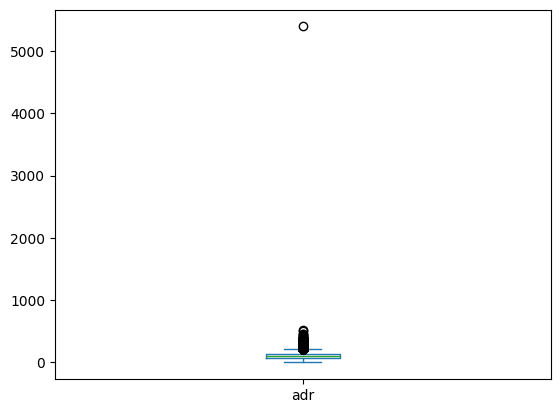

In [15]:
hotel['adr'].plot(kind='box')

In [7]:
hotel=hotel[hotel['adr']<500]

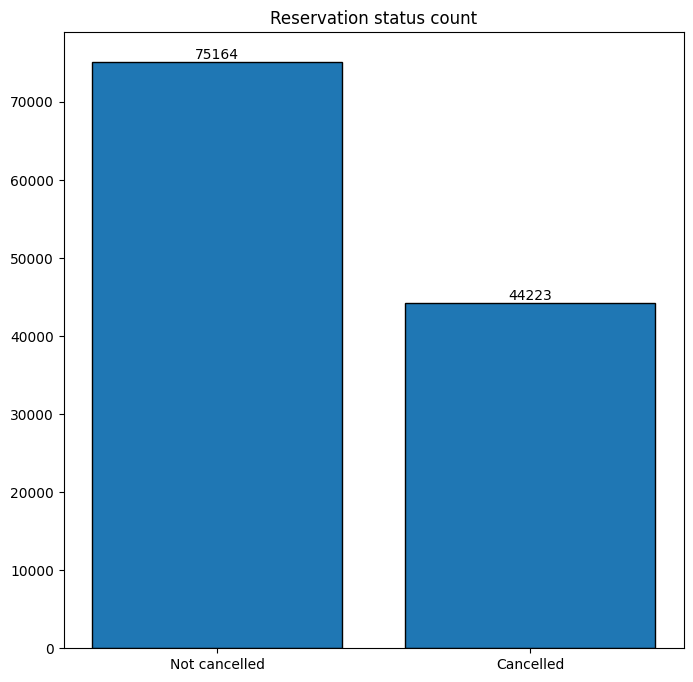

In [15]:
cancelled_count = hotel['is_canceled'].value_counts().sort_index()

plt.figure(figsize=(8,8))
plt.title('Reservation status count')

bars = plt.bar(['Not cancelled','Cancelled'],
               cancelled_count,
               edgecolor='k')

# Add numbers on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval,
             int(yval),
             ha='center',
             va='bottom')

plt.show()

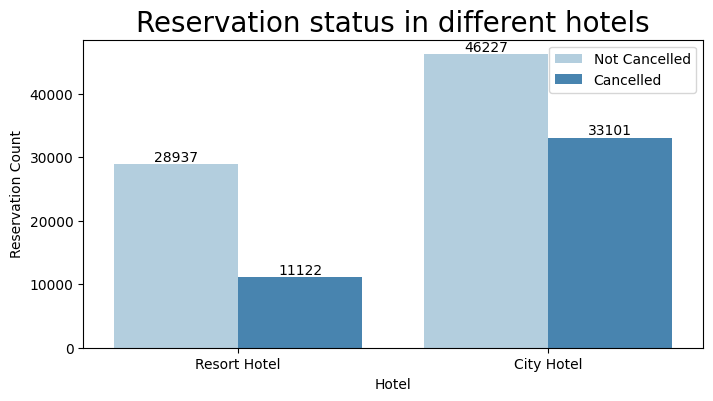

In [21]:
plt.figure(figsize=(8,4))

ax1 = sns.countplot(
    x='hotel',
    hue='is_canceled',
    data=hotel,
    palette='Blues'
)

# Add numbers on bars
for p in ax1.patches:
    height = p.get_height()
    if height > 0:  # avoid showing 0
        ax1.text(
            p.get_x() + p.get_width()/2,
            height,
            int(height),
            ha='center',
            va='bottom'
        )

# Legend
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles, ['Not Cancelled', 'Cancelled'], bbox_to_anchor=(1,1))

plt.title('Reservation status in different hotels', size=20)
plt.xlabel('Hotel')
plt.ylabel('Reservation Count')

plt.show()

In [22]:
resort_hotel=hotel[hotel['hotel']=='Resort Hotel']
resort_hotel['is_canceled'].value_counts(normalize=True)


,proportion
is_canceled,
0,0.72236
1,0.27764


In [26]:
city_hotel=hotel[hotel['hotel']=='City Hotel']
city_hotel['is_canceled'].value_counts(normalize=True)


,proportion
is_canceled,
0,0.582732
1,0.417268


In [35]:
# Separate data
city_hotel = hotel[hotel['hotel'] == 'City Hotel']
resort_hotel = hotel[hotel['hotel'] == 'Resort Hotel']

# 1️⃣ Cancellation percentage (KEEP this exactly)
city_hotel['is_canceled'].value_counts(normalize=True)
resort_hotel['is_canceled'].value_counts(normalize=True)

# 2️⃣ ADR trend (separate variable — no overwrite)
city_hotel_adr = city_hotel.groupby('reservation_status_date')['adr'].mean().reset_index()

resort_hotel_adr = resort_hotel.groupby('reservation_status_date')['adr'].mean().reset_index()

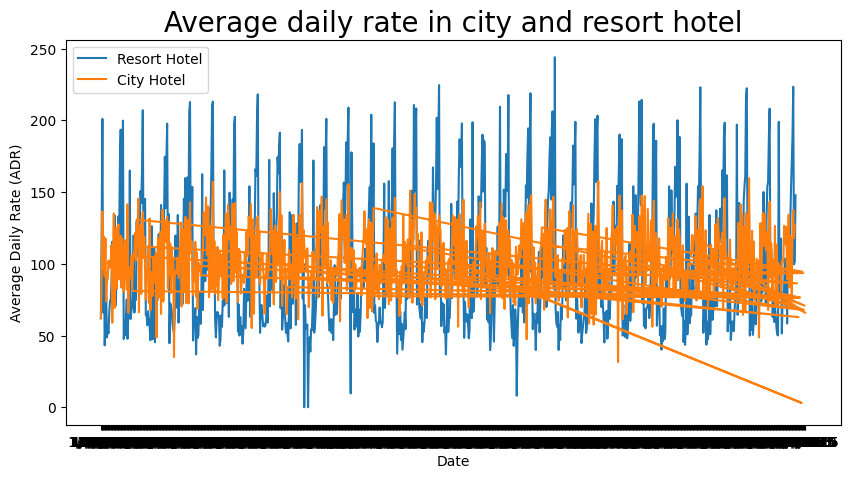

In [36]:
plt.figure(figsize=(10,5))

plt.title('Average daily rate in city and resort hotel', fontsize=20)

# Resort hotel line
plt.plot(resort_hotel_adr['reservation_status_date'],
         resort_hotel_adr['adr'],
         label='Resort Hotel')

# City hotel line
plt.plot(city_hotel_adr['reservation_status_date'],
         city_hotel_adr['adr'],
         label='City Hotel')

plt.xlabel('Date')
plt.ylabel('Average Daily Rate (ADR)')

plt.legend()
plt.show()

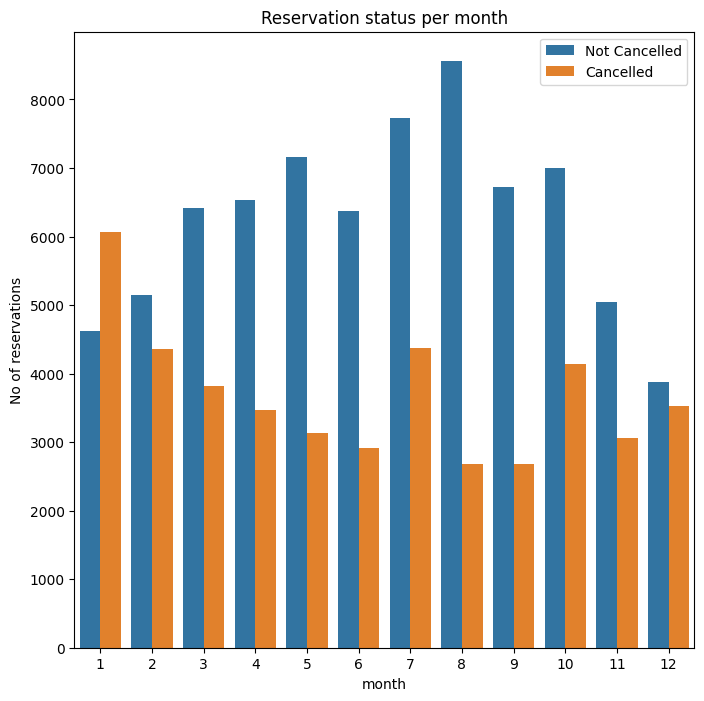

In [40]:
hotel['month'] = hotel['reservation_status_date'].dt.month

plt.figure(figsize=(8,8))

ax1 = sns.countplot(x='month', hue='is_canceled', data=hotel)
plt.title('Reservation status per month')

plt.ylabel('No of reservations')

# Fix legend properly
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles, ['Not Cancelled', 'Cancelled'])

plt.show()

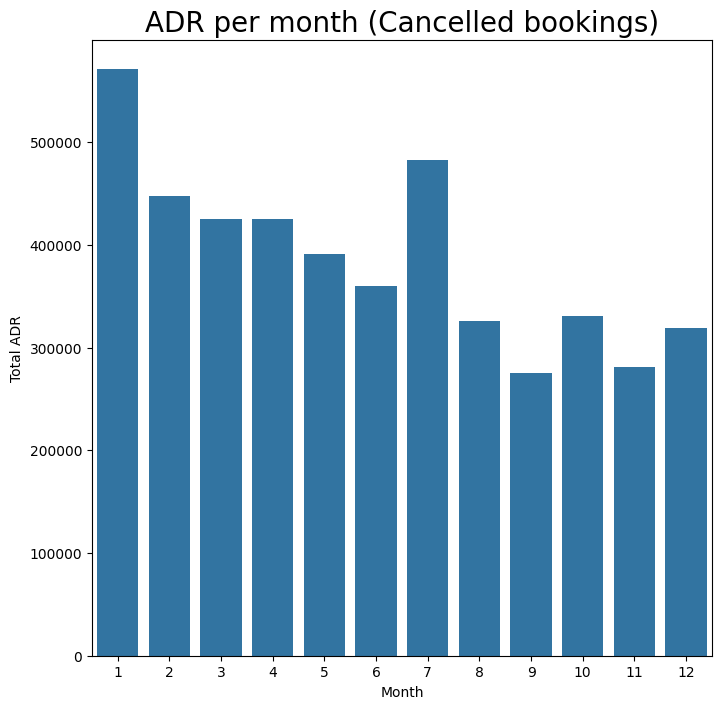

In [42]:
# Prepare data properly
monthly_adr = hotel[hotel['is_canceled'] == 1] \
                .groupby('month')['adr'].sum() \
                .reset_index()

plt.figure(figsize=(8,8))
plt.title('ADR per month (Cancelled bookings)', fontsize=20)

sns.barplot(x='month', y='adr', data=monthly_adr)

plt.xlabel('Month')
plt.ylabel('Total ADR')

plt.show()

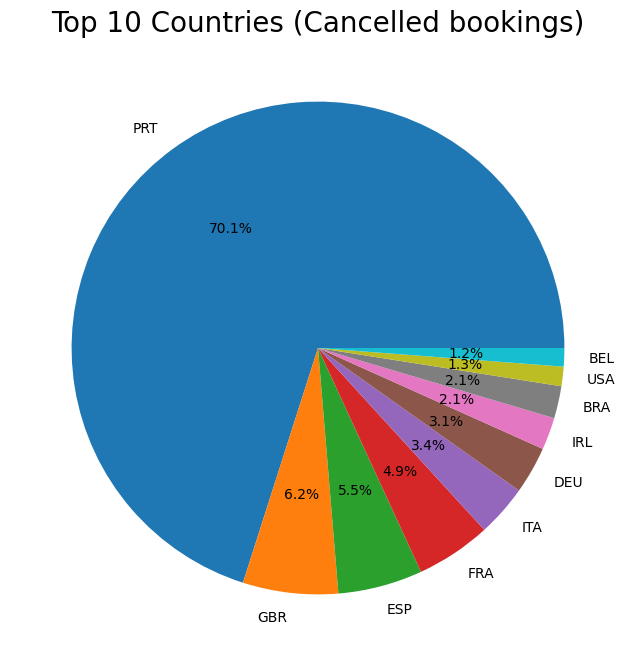

In [46]:
cancelled_data = hotel[hotel['is_canceled'] == 1]

top_10_country = cancelled_data['country'].value_counts()[:10]

plt.figure(figsize=(8,8))
plt.title('Top 10 Countries (Cancelled bookings)', fontsize=20)

plt.pie(top_10_country,
        labels=top_10_country.index,
        autopct='%1.1f%%')

plt.show()

In [48]:
hotel['market_segment'].value_counts(normalize=True)

,proportion
market_segment,
Online TA,0.473058
Offline TA/TO,0.202845
Groups,0.165939
Direct,0.105589
Corporate,0.044343
Complementary,0.006223
Aviation,0.001985
Undefined,0.000017


In [50]:
cancelled_data ['market_segment'].value_counts(normalize=True)

,proportion
market_segment,
Online TA,0.468964
Groups,0.273545
Offline TA/TO,0.187911
Direct,0.043733
Corporate,0.022432
Complementary,0.002193
Aviation,0.001176
Undefined,0.000045


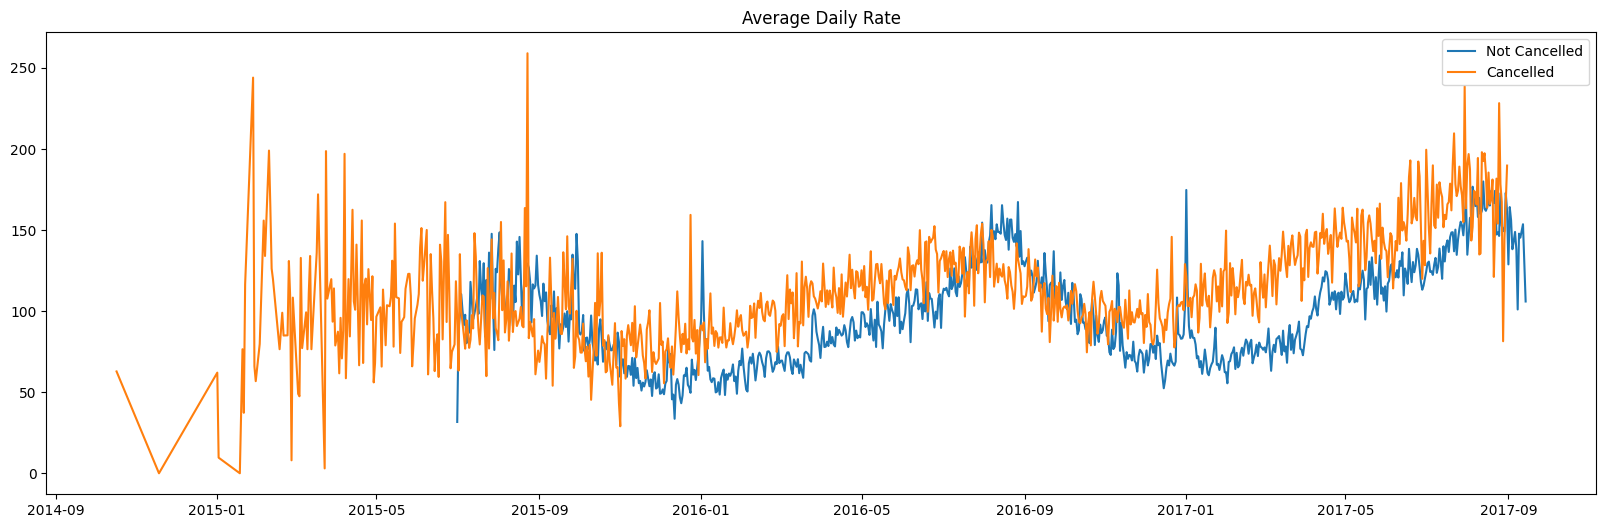

In [54]:
# Create datasets
cancelled_data = hotel[hotel['is_canceled'] == 1]
not_cancelled = hotel[hotel['is_canceled'] == 0]

# Grouping
cancelled_df_adr = cancelled_data.groupby('reservation_status_date')[['adr']].mean()
cancelled_df_adr.reset_index(inplace=True)
cancelled_df_adr.sort_values('reservation_status_date', inplace=True)

not_cancelled_df_adr = not_cancelled.groupby('reservation_status_date')[['adr']].mean()
not_cancelled_df_adr.reset_index(inplace=True)
not_cancelled_df_adr.sort_values('reservation_status_date', inplace=True)

# Plot
plt.figure(figsize=(20,6))
plt.title('Average Daily Rate')

plt.plot(not_cancelled_df_adr['reservation_status_date'],
         not_cancelled_df_adr['adr'],
         label='Not Cancelled')

plt.plot(cancelled_df_adr['reservation_status_date'],
         cancelled_df_adr['adr'],
         label='Cancelled')

plt.legend()
plt.show()